## 1. Setup

### 1.1 Importar Libs

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import pickle
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform, uniform, randint
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import evaluate_model, load_and_prepare_datasets, SCORING_METRIC
from search_utils import (plot_search_history, multiple_randomized_search,
                          plot_search_history_from_loaded, 
                          load_search_results, get_best_params_from_saved,
                          save_search_results, save_final_results, 
                          DEFAULT_CV_STRATEGY, SEARCHES_FOLDER, MODELS_FOLDER, RESULTS_FOLDER)

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Bibliotecas importadas com sucesso!
Pandas: 2.3.3
NumPy: 2.2.6
Scikit-learn: 1.7.2


### 1.2 Configuração do Modelo

In [9]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "MLP"
MODEL_CLASS = MLPClassifier
RANDOM_STATE_MODEL = 42
RANDOM_STATE_SAMPLE = 10

# Configuração da busca de hiperparâmetros
# Aumentando iterações para explorar melhor o espaço otimizado
N_SEARCHES = 30
N_ITER_PER_SEARCH = 5  # Aumentado de 10 para 40 para melhor exploração
SAMPLE_SIZE = 0.01  # % of training data for hyperparameter search

print(f"Modelo configurado: {MODEL_NAME}")
print(f"Buscas: {N_SEARCHES} x {N_ITER_PER_SEARCH} iterações")
print(f"Total de configurações a testar: {N_SEARCHES * N_ITER_PER_SEARCH}")

Modelo configurado: MLP
Buscas: 30 x 5 iterações
Total de configurações a testar: 150


## 2. Carregamento e Preparação dos Dados

In [4]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, train_data, test_data, scaler = load_and_prepare_datasets()

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", y_train.value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

print("\nPrimeiras linhas do dataset de treino:")

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)
Features: 1824

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}

Primeiras linhas do dataset de treino:
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)
Features: 1824

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}

Primeiras linhas do dataset de treino:


In [6]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,1815,1816,1817,1818,1819,1820,1821,1822,1823,digit
0,0.132290,-0.078874,-0.007970,0.126206,-0.019496,0.049232,0.118899,-0.035883,0.027992,0.031445,...,1.514577,1.355709,1.418220,1.314246,1.393841,1.382280,1.272189,1.350409,1.342505,1
1,-1.261489,-1.223371,-1.000089,-1.225078,-1.232434,-0.959512,-1.124728,-1.226982,-0.848620,-1.207445,...,-1.251411,-1.451988,-1.167611,-1.313675,-1.466612,-1.229501,-1.268458,-1.301135,-1.067532,1
2,-0.803139,-0.742865,-0.624391,-0.887569,-0.834537,-0.721469,-0.968023,-0.922214,-0.717852,-0.951887,...,-1.567787,-1.773163,-1.590253,-1.399433,-1.590376,-1.392650,-1.309864,-1.443503,-1.416043,1
3,0.495477,0.708491,0.804662,0.502907,0.720904,0.816273,0.587815,0.800239,0.893713,0.593013,...,0.951751,0.926661,1.139622,0.921222,0.899732,1.112191,0.930080,0.907232,1.048508,2
4,0.731854,0.843948,0.588933,0.628960,0.746698,0.552313,0.452046,0.575681,0.506712,0.329009,...,0.918366,0.802927,0.817431,0.947489,0.807747,0.683944,0.860839,0.730585,0.559723,2


## 3. Sampling para Busca de Hiperparâmetros

In [7]:
# ======================================================================
# SAMPLING ESTRATIFICADO PARA BUSCA DE HIPERPARÂMETROS
# ======================================================================

print("=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===")

# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train, 
    test_size=SAMPLE_SIZE,  
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", y_train.value_counts().to_dict())

=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===
Dataset original de treino: 37,233 amostras
Amostra para busca de hiperparâmetros: 373 amostras
Redução: 99.0%

Distribuição das classes na amostra:
Amostra: {1: 71, 2: 56, 3: 43, 4: 37, 5: 34, 7: 29, 6: 29, 0: 25, 8: 25, 9: 24}
Original: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Dataset original de treino: 37,233 amostras
Amostra para busca de hiperparâmetros: 373 amostras
Redução: 99.0%

Distribuição das classes na amostra:
Amostra: {1: 71, 2: 56, 3: 43, 4: 37, 5: 34, 7: 29, 6: 29, 0: 25, 8: 25, 9: 24}
Original: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}


## 4. Definir Estratégia de Validação Cruzada

In [8]:
# Usar estratégia de CV padrão dos módulos
print(f"Estratégia de CV: {DEFAULT_CV_STRATEGY}")

Estratégia de CV: StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


## 5. MLP - Busca de Hiperparâmetros


### 5.1 Definir Espaço de Hiperparâmetros


In [10]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# ======================================================================

# Definir hiperparâmetros específicos para MLP
# Configuração base que funcionou bem: (1024, 256), max_iter=500
# Resultado:
#       Training Accuracy: 0.9836 (98.36%)
#       Validation Accuracy: 0.8151 (81.51%)

param_distributions = {
    # Variações de arquitetura focadas em torno de (1024, 256)
    'hidden_layer_sizes': [
        # Arquiteturas de 1 camada
        (256,),
        (512,),
        (1024,),
        (128,),
        (2048,),

        # Arquiteturas de 2 camadas (similar à base)
        (1024, 256),           # Configuração base que funcionou
        (1024, 512),           # Segunda camada maior
        (1024, 128),           # Segunda camada menor
        (512, 256),            # Primeira camada menor
        (2048, 256),           # Primeira camada maior
        (1024, 384),           # Segunda camada intermediária
        (768, 256),            # Primeira camada intermediária
        (1024, 192),           # Segunda camada intermediária
        
        # Arquiteturas de 3 camadas (expansão da base)
        (1024, 512, 256),      # Decrescente suave
        (1024, 256, 128),      # Continuando decrescente
        (512, 256, 128),       # Menor mas decrescente
        (1024, 512, 128),      # Decrescente mais agressivo
        (2048, 512, 256),      # Maior em todas as camadas
        
        # Arquiteturas alternativas
        (512, 512, 256),       # Camadas iniciais iguais
        (1024, 1024, 256),     # Mantém tamanho grande por mais tempo
        (768, 512, 256),       # Decrescente moderado
    ],
    
    'alpha': loguniform(1e-5, 1e-1),                # Regularização L2 (log scale)
    'learning_rate_init': loguniform(1e-4, 1e-1),   # Taxa de aprendizado inicial
    'max_iter': randint(200, 800),                  # Número máximo de iterações
    'activation': ['relu', 'tanh', 'logistic'],              # Função de ativação
    'learning_rate': ['constant', 'adaptive', 'invscaling'],  # Estratégia de taxa de aprendizado
    'solver': ['lbfgs','adam', 'sgd'],                       # Solver 
}

### 5.2 Executar Busca de Hiperparâmetros

In [ ]:
# ======================================================================
# BUSCA DE HIPERPARAMETROS
# ======================================================================

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Executando {N_SEARCHES} buscas com {N_ITER_PER_SEARCH} iterações cada...")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")

# Múltiplas execuções do RandomizedSearchCV
search, all_searches, best_params = multiple_randomized_search(
    estimator=MODEL_CLASS(random_state=RANDOM_STATE_MODEL, early_stopping=True),
    param_distributions=param_distributions,
    X=X_sample,
    y=y_sample,
    cv_strategy=DEFAULT_CV_STRATEGY,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    n_jobs=-1
)

# Exibir os melhores resultados
print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {search.best_score_:.4f}")
print(f"Desvio padrão: {search.cv_results_['std_test_score'][search.best_index_]:.4f}")

=== BUSCA DE HIPERPARÂMETROS - MLP ===
Iniciando busca de hiperparâmetros para MLP...
Executando 30 buscas com 5 iterações cada...
Usando amostra de 373 exemplos

Executando 30 buscas com 5 iterações cada...

Busca 1/30...


### 5.3 Visualizar Histórico da Busca

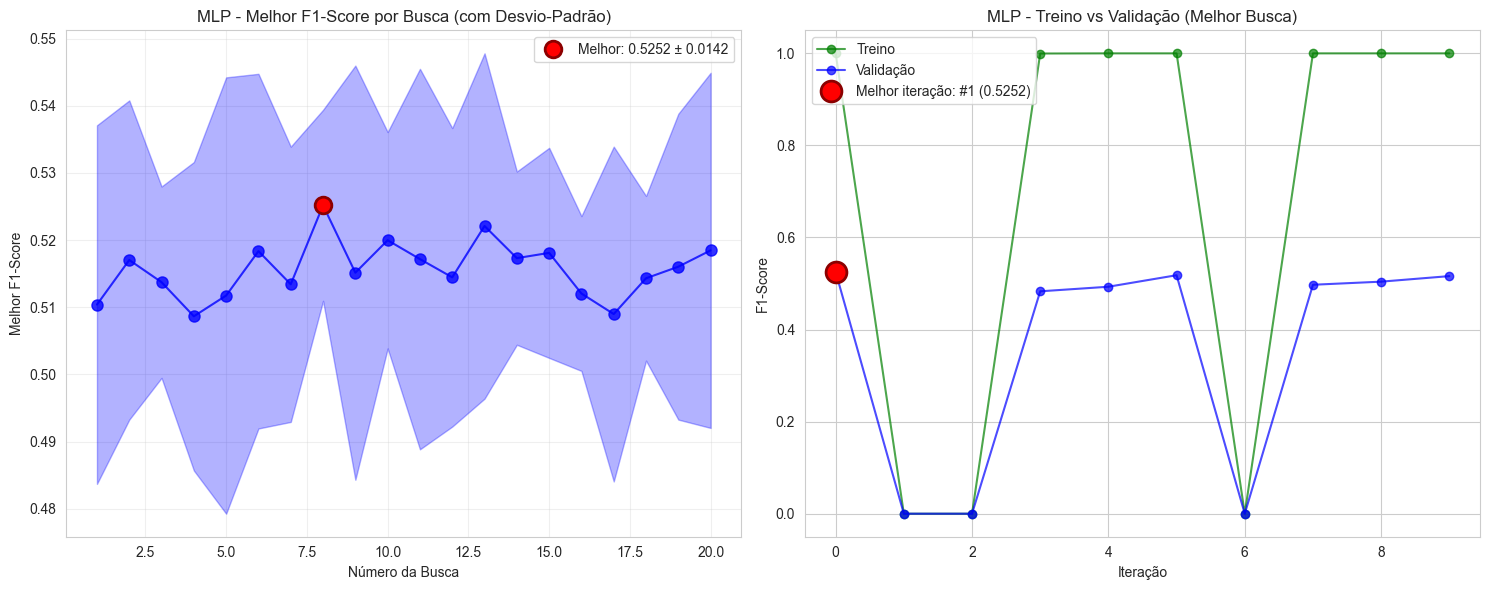

In [ ]:
# Registro de Desempenho - plotar evolução da busca
plot_search_history(all_searches, search, MODEL_NAME)

In [ ]:
# ======================================================================
# ANÁLISE DAS MELHORES CONFIGURAÇÕES ENCONTRADAS
# ======================================================================

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - {MODEL_NAME} ===")

# Extrair os melhores resultados de cada busca
best_configs = []

for i, search_result in enumerate(all_searches):
    config = {
        'Busca': i + 1,
        'F1_Score': search_result['best_score'],
        **search_result['best_params']
    }
    best_configs.append(config)

# Criar DataFrame e exibir top configs
results_df = pd.DataFrame(best_configs)
results_df = results_df.sort_values('F1_Score', ascending=False).round(4)

print(f"\nTop configurações (de {len(results_df)} buscas):")
print(results_df.to_string(index=False))

print(f"\nEstatísticas dos F1-Scores encontrados:")
print(f"  Média: {results_df['F1_Score'].mean():.4f}")
print(f"  Mediana: {results_df['F1_Score'].median():.4f}")
print(f"  Desvio padrão: {results_df['F1_Score'].std():.4f}")
print(f"  Min: {results_df['F1_Score'].min():.4f}")
print(f"  Max: {results_df['F1_Score'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - MLP ===
Melhores Configurações de Cada Busca (ordenadas por F1-Score Binário):
------------------------------------------------------------------------------------------------------------------------------------------------------
 Ranking  Busca  F1_Score        Hidden_Layers  Alpha  Learning_Rate_Init Learning_Rate  Max_Iter Activation
       1      8    0.5252      (100, 100, 100) 0.0921              0.0302    invscaling       538       relu
       2     13    0.5221  (300, 200, 100, 50) 0.0272              0.0317      adaptive       357       relu
       3     10    0.5200 (200, 200, 200, 200) 0.0672              0.0727    invscaling       529       relu
       4     20    0.5185      (200, 300, 100) 0.0816              0.0835      constant       507       tanh
       5      6    0.5184 (100, 100, 100, 100) 0.0284              0.0290    invscaling       465       tanh
       6     15    0.5181 (200, 200, 200, 200) 0.0662            

## 6. Salvar Resultados de Busca

In [ ]:

search_df = save_search_results(
    model_name=MODEL_NAME,
    model_search=search,
    model_all_searches=all_searches,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    cv_folds=DEFAULT_CV_STRATEGY.get_n_splits(),
    top_params_columns=param_distributions.keys(),
    searches_folder=SEARCHES_FOLDER
)

=== SALVANDO RESULTADOS DA BUSCA - MLP ===
  ✅ Todos os Resultados salvos: searches/mlp_all_searches.csv
  Total de configurações testadas: 200
  ✅ Resumo salvo: searches/mlp_search_summary.json

--- ESTATÍSTICAS DA BUSCA MLP ---
Melhor F1-Score: 0.5252
Desvio padrão do melhor: 0.0142
F1-Score médio geral: 0.3998
F1-Score mínimo: 0.0000
F1-Score máximo: 0.5252


### 6.2 Carregar Resultado de Busca (Opcional)

In [ ]:
loaded_results = load_search_results(MODEL_NAME)

=== CARREGANDO RESULTADOS DE BUSCA - MLP ===
✅ Resultados detalhados carregados: 200 configurações
✅ Resumo carregado: F1-Score = 0.5252
⚠️  Arquivo não encontrado: searches/mlp_full_search.pkl


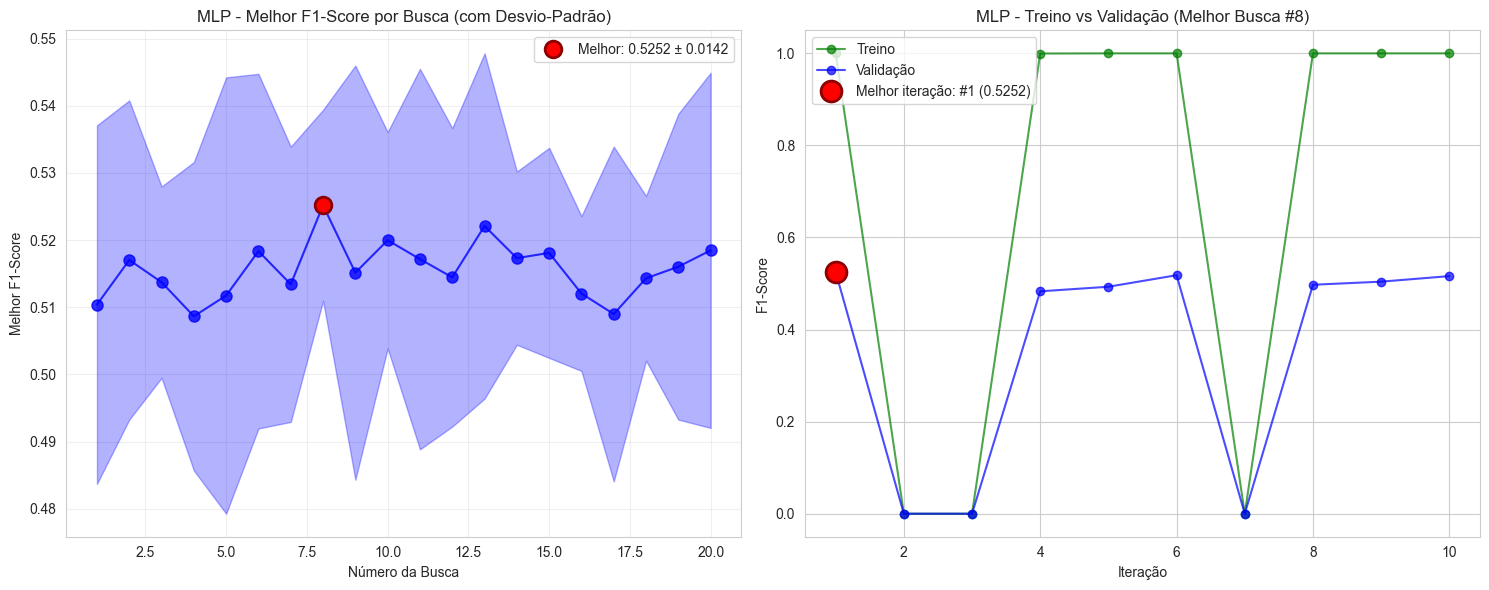

In [ ]:
# Plotar a história da busca a partir dos resultados carregados
plot_search_history_from_loaded(loaded_results, MODEL_NAME)

### 6.3 Definir Melhores Params e CV score

In [ ]:
# Definir Melhores Parâmetros para Uso Posterior
if 'loaded_results' in locals():
    best_params = get_best_params_from_saved(MODEL_NAME)
    best_score = loaded_results['summary']['best_overall_score']
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor F1-Score carregado: {best_score:.4f}")
else:
    best_params = search.best_params_
    best_score = search.best_score_
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor F1-Score da busca atual: {best_score:.4f}")

✅ Parâmetros carregados: {'activation': 'relu', 'alpha': 0.09206404629626241, 'hidden_layer_sizes': '(100, 100, 100)', 'learning_rate': 'invscaling', 'learning_rate_init': 0.0302435297502903, 'max_iter': 538}
✅ Melhor F1-Score carregado: 0.5252


## 7. Treinar Modelo Final e Salvar

In [ ]:
# Treinamento Final com melhores hiperparâmetros

best_model = MODEL_CLASS(random_state=RANDOM_STATE_MODEL, **best_params)
best_model.fit(X_train_scaled, y_train)
print(f"\nModelo final {MODEL_NAME} treinado com dataset completo: {best_model}")

Tipo de best_params: <class 'str'>


In [ ]:

# Save the trained model immediately after training
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")


Modelo final MLP treinado: MLPClassifier(alpha=0.09206404629626241, hidden_layer_sizes=(100, 100, 100),
              learning_rate='invscaling', learning_rate_init=0.0302435297502903,
              max_iter=538, random_state=42)


## 8. Avaliação Final e Salvamento dos Resultados

In [ ]:
# Carregar modelo (Opcional)
loaded_model = load(os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib'))

In [ ]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando performance do modelo...")

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, test_metrics, y_test_pred = evaluate_model(
    best_model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, MODEL_NAME
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - MLP ===

Avaliando performance do modelo...


### 8.1 Classification Report

In [ ]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

### 8.2 Visualize Confusion Matrix

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [ ]:
# Salvar resultados finais usando função do módulo
model_final_results = save_final_results(
    model_name=MODEL_NAME,
    best_params=best_params,
    best_score=best_score,
    train_metrics=train_metrics,
    test_metrics=test_metrics,
    y_pred=y_test_pred,
    y_test=y_test_eval,
    X_train_scaled=X_train_eval,
    X_test_scaled=X_test_eval,
    results_folder=RESULTS_FOLDER
)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"F1-Score CV: {model_final_results['best_cv_score']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"G-Mean Teste: {test_metrics['gmean']:.4f}")

print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"\nAvaliação do {MODEL_NAME} concluída com sucesso!")

✅ Resultados MLP salvos em: results/mlp_results.json

--- RESUMO MLP ---
F1-Score CV: 0.5252
F1-Score Teste: 0.5916
Acurácia Teste: 0.7973
Precisão Teste: 0.6770
Recall Teste: 0.5254
G-Mean Teste: 0.6887
AUC-ROC Teste: 0.8096
